<a href="https://colab.research.google.com/github/tyn275/Handwritten-Digit-Recognition/blob/main/BaseCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Kiểm tra GPU khả dụng, ưu tiên CUDA (GPU NVIDIA), fallback về CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị đang sử dụng: {device}")

Thiết bị đang sử dụng: cuda


In [2]:
SEED = 42  # Hằng số seed, thay đổi con số này nếu muốn thử nghiệm khác

def set_seed(seed: int):
    random.seed(seed)                            # Seed cho thư viện random chuẩn của Python
    os.environ['PYTHONHASHSEED'] = str(seed)     # Seed cho hash của Python (ảnh hưởng dict, set)
    np.random.seed(seed)                         # Seed cho NumPy
    torch.manual_seed(seed)                      # Seed cho PyTorch trên CPU
    torch.cuda.manual_seed(seed)                 # Seed cho GPU hiện tại
    torch.cuda.manual_seed_all(seed)             # Seed cho tất cả GPU (nếu dùng multi-GPU)

    # Ép cuDNN chạy theo thuật toán cố định
    torch.backends.cudnn.deterministic = True
    # Tắt auto-tuning
    torch.backends.cudnn.benchmark = False

    # Cảnh báo thay vì crash nếu có op không hỗ trợ deterministic
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)
print(f"Đã cố định seed = {SEED}")

Đã cố định seed = 42


In [3]:
# --- 3.1 Định nghĩa pipeline tiền xử lý ảnh ---
transform = transforms.Compose([
    # Chuyển ảnh PIL (uint8, 0-255) thành FloatTensor (float32, 0.0-1.0)
    # Đồng thời chuyển shape từ (H, W) sang (C, H, W) = (1, 28, 28)
    transforms.ToTensor(),
])

# --- 3.2 Tải dataset MNIST ---
# train=True  -> 60,000 ảnh huấn luyện
# train=False -> 10,000 ảnh kiểm tra cuối cùng (KHÔNG được dùng khi train)
full_train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset       = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# --- 3.3 Tách Validation từ Train ---
# Dùng generator cố định để random_split luôn tách cùng một tập ảnh
val_ratio  = 0.1                                          # 10% dùng làm validation
train_size = int((1 - val_ratio) * len(full_train_dataset))  # 54,000 ảnh
val_size   = len(full_train_dataset) - train_size            # 6,000 ảnh

split_generator = torch.Generator().manual_seed(SEED)     # Generator riêng cho việc tách tập

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=split_generator   # Đảm bảo tách cùng một nhóm ảnh mỗi lần chạy
)

# --- 3.4 Đóng gói vào DataLoader ---
# DataLoader chia dataset thành các batch và tải song song lên bộ nhớ

# Generator riêng cho shuffle của DataLoader (tách biệt khỏi split_generator)
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,          # Mỗi bước học dùng 64 ảnh
    shuffle=True,           # Xáo trộn thứ tự ảnh sau mỗi epoch để tránh học theo thứ tự
    num_workers=0,          # Trên Colab nên để 0 (tránh lỗi multiprocessing)
    generator=loader_generator  # Seed cho shuffle -> thứ tự batch ổn định
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1000,        # Batch lớn để đánh giá nhanh hơn (không cần gradient)
    shuffle=False,          # Không cần xáo trộn khi đánh giá
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=0
)

# --- 3.5 Tóm tắt ---
print(f"Dữ liệu đã sẵn sàng:")
print(f"  Train      : {len(train_dataset):,} ảnh  | {len(train_loader)} batch x 64")
print(f"  Validation : {len(val_dataset):,}  ảnh  | {len(val_loader)} batch x 1000")
print(f"  Test       : {len(test_dataset):,} ảnh  | {len(test_loader)} batch x 1000")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 472kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.37MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.66MB/s]

Dữ liệu đã sẵn sàng:
  Train      : 54,000 ảnh  | 844 batch x 64
  Validation : 6,000  ảnh  | 6 batch x 1000
  Test       : 10,000 ảnh  | 10 batch x 1000


In [4]:
#   - features   : Trích xuất đặc trưng không gian từ ảnh (Conv + Pool)
#   - classifier : Phân loại dựa trên đặc trưng đã trích (Linear)
class BaseCNN(nn.Module):
    def __init__(self):
        super(BaseCNN, self).__init__()

        # ── KHỐI TRÍCH XUẤT ĐẶC TRƯNG ──────────────────────────
        self.features = nn.Sequential(

            # Conv2D_1: Học các đặc trưng cơ bản (cạnh ngang, dọc, chéo)
            # in_channels=1  : ảnh grayscale 1 kênh
            # out_channels=32: tạo ra 32 bản đồ đặc trưng (feature maps)
            # kernel_size=3  : cửa sổ trượt 3x3 pixel
            # Output shape: (B, 32, 26, 26)  vì 28-3+1=26
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),  # Hàm kích hoạt: giữ giá trị dương, đặt âm về 0

            # MaxPool2D_1: Lấy giá trị lớn nhất trong ô 2x2
            # Tác dụng: Giảm chiều không gian xuống 1/2, giảm tính toán
            # và tạo tính bất biến vị trí (chữ số lệch nhẹ vẫn nhận ra)
            # Output shape: (B, 32, 13, 13)  vì 26/2=13
            nn.MaxPool2d(kernel_size=2),

            # Conv2D_2: Học đặc trưng phức tạp hơn (vòng cong, nét nối)
            # in_channels=32 : nhận 32 feature maps từ lớp trước
            # out_channels=64: tăng gấp đôi filter (quy tắc kinh điển)
            # Output shape: (B, 64, 11, 11)  vì 13-3+1=11
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),

            # MaxPool2D_2: Giảm tiếp xuống 1/2
            # Output shape: (B, 64, 5, 5)  vì floor(11/2)=5
            nn.MaxPool2d(kernel_size=2),

            # Dropout_1 (p=0.25): Tắt ngẫu nhiên 25% neuron khi training
            # Ép model không phụ thuộc vào feature nào quá nhiều -> chống overfit
            # Khi eval() được gọi, Dropout tự động tắt (dùng toàn bộ neuron)
            nn.Dropout(0.25)
        )

        # ── KHỐI PHÂN LOẠI ──────────────────────────────────────
        self.classifier = nn.Sequential(

            # Flatten: Duỗi tensor 3D (64, 5, 5) thành vector 1D
            # 64 * 5 * 5 = 1600 phần tử
            # Output shape: (B, 1600)
            nn.Flatten(),

            # Dense_1: Liên kết đầy đủ 1600 -> 128 neuron
            # Học cách kết hợp các đặc trưng không gian thành đặc trưng ngữ nghĩa
            nn.Linear(in_features=64 * 5 * 5, out_features=128),
            nn.ReLU(),

            # Dropout_2 (p=0.5): Tắt 50% neuron ở lớp Dense (tỷ lệ cao hơn vì Dense dễ overfit)
            nn.Dropout(0.5),

            # Output: 128 -> 10 neuron tương ứng 10 lớp chữ số (0-9)
            # Không dùng Softmax ở đây vì CrossEntropyLoss tự tính log-softmax bên trong
            nn.Linear(in_features=128, out_features=10)
        )

    def forward(self, x):
        # Luồng dữ liệu: ảnh đầu vào -> trích xuất đặc trưng -> phân loại -> logits đầu ra
        x = self.features(x)
        x = self.classifier(x)
        return x  # Trả về logits (điểm số thô, chưa qua softmax)


# Khởi tạo model và đưa lên device (GPU hoặc CPU)
model = BaseCNN().to(device)

# In cấu trúc model để kiểm tra
print("Kiến trúc Base CNN:")
print(model)
print(f"\nTổng số tham số: {sum(p.numel() for p in model.parameters()):,}")
print(f"Tham số có thể học: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Kiến trúc Base CNN:
BaseCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Tổng số tham số: 225,034
Tham số có thể học: 225,034


In [5]:
# CrossEntropyLoss = LogSoftmax + NLLLoss
criterion = nn.CrossEntropyLoss()

# Adam: Bộ tối ưu thích nghi learning rate cho từng tham số
# - Kết hợp momentum (tích lũy hướng đi) và RMSProp (chuẩn hóa gradient)
# - lr=0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam  (lr=0.001)")

Loss function : CrossEntropyLoss
Optimizer     : Adam  (lr=0.001)


In [6]:
EPOCHS = 10
best_val_loss = float('inf')  # Lưu val_loss nhỏ nhất để chọn checkpoint tốt nhất

# Lưu lịch sử các chỉ số qua từng epoch để vẽ đồ thị sau
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':  []
}

print("=" * 65)
print("BẮT ĐẦU HUẤN LUYỆN")
print("=" * 65)

for epoch in range(EPOCHS):

    # ── GIAI ĐOẠN TRAIN ─────────────────────────────────────
    model.train()  # Bật chế độ train: kích hoạt Dropout, BatchNorm (nếu có)

    train_loss_sum = 0.0
    train_correct  = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # Chuyển lên GPU

        optimizer.zero_grad()           # Xóa gradient của batch trước (tránh tích lũy)
        outputs = model(images)         # Forward pass: tính logits
        loss = criterion(outputs, labels)  # Tính loss giữa logits và nhãn thật
        loss.backward()                 # Backward pass: tính gradient theo loss
        optimizer.step()                # Cập nhật trọng số theo gradient

        # Tích lũy loss (nhân với batch size để tính trung bình chính xác sau)
        train_loss_sum += loss.item() * images.size(0)

        # Đếm số ảnh đoán đúng: lấy class có logit cao nhất
        preds = outputs.argmax(dim=1)
        train_correct += preds.eq(labels).sum().item()

    # Tính trung bình trên toàn tập train
    epoch_train_loss = train_loss_sum / len(train_loader.dataset)
    epoch_train_acc  = 100.0 * train_correct / len(train_loader.dataset)

    # ── GIAI ĐOẠN VALIDATION ────────────────────────────────
    model.eval()  # Tắt chế độ train: vô hiệu hóa Dropout để đánh giá ổn định

    val_loss_sum = 0.0
    val_correct  = 0

    with torch.no_grad():  # Tắt tính gradient -> tiết kiệm bộ nhớ, tăng tốc
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += preds.eq(labels).sum().item()

    epoch_val_loss = val_loss_sum / len(val_loader.dataset)
    epoch_val_acc  = 100.0 * val_correct / len(val_loader.dataset)

    # ── GHI LỊCH SỬ ─────────────────────────────────────────
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f}  Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}  Acc: {epoch_val_acc:.2f}%")

    # ── LƯU CHECKPOINT TỐT NHẤT ─────────────────────────────
    # Chỉ lưu khi val_loss giảm (model đang tốt hơn trên dữ liệu chưa thấy)
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'BaseCNN_best.pt')  # Chỉ lưu weights, không lưu cả model
        print(f"⭐ Val loss mới tốt nhất ({best_val_loss:.4f}) — đã lưu BaseCNN_best.pt")

print("=" * 65)
print("HUẤN LUYỆN HOÀN TẤT")
print("=" * 65)

BẮT ĐẦU HUẤN LUYỆN
Epoch 01/10 | Train Loss: 0.3173  Acc: 90.29% | Val Loss: 0.0779  Acc: 97.67%
⭐ Val loss mới tốt nhất (0.0779) — đã lưu BaseCNN_best.pt
Epoch 02/10 | Train Loss: 0.1128  Acc: 96.74% | Val Loss: 0.0651  Acc: 98.25%
⭐ Val loss mới tốt nhất (0.0651) — đã lưu BaseCNN_best.pt
Epoch 03/10 | Train Loss: 0.0856  Acc: 97.48% | Val Loss: 0.0502  Acc: 98.57%
⭐ Val loss mới tốt nhất (0.0502) — đã lưu BaseCNN_best.pt
Epoch 04/10 | Train Loss: 0.0703  Acc: 97.93% | Val Loss: 0.0495  Acc: 98.52%
⭐ Val loss mới tốt nhất (0.0495) — đã lưu BaseCNN_best.pt
Epoch 05/10 | Train Loss: 0.0632  Acc: 98.09% | Val Loss: 0.0422  Acc: 98.78%
⭐ Val loss mới tốt nhất (0.0422) — đã lưu BaseCNN_best.pt
Epoch 06/10 | Train Loss: 0.0561  Acc: 98.26% | Val Loss: 0.0440  Acc: 98.97%
Epoch 07/10 | Train Loss: 0.0512  Acc: 98.45% | Val Loss: 0.0355  Acc: 99.08%
⭐ Val loss mới tốt nhất (0.0355) — đã lưu BaseCNN_best.pt
Epoch 08/10 | Train Loss: 0.0465  Acc: 98.59% | Val Loss: 0.0358  Acc: 99.02%
Epoch 09/

In [7]:
# Tạo model mới và nạp weights đã lưu
test_model = BaseCNN().to(device)
test_model.load_state_dict(torch.load('BaseCNN_best.pt', map_location=device))
test_model.eval()

test_loss_sum = 0.0
test_correct  = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = test_model(images)
        loss = criterion(outputs, labels)

        test_loss_sum += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        test_correct += preds.eq(labels).sum().item()

test_loss = test_loss_sum / len(test_loader.dataset)
test_acc  = 100.0 * test_correct / len(test_loader.dataset)
test_wrong = len(test_loader.dataset) - test_correct

print("── KẾT QUẢ TRÊN TẬP TEST ──────────────────────────────")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.2f}%")
print(f"  Số mẫu test   : {len(test_loader.dataset):,}")
print(f"  Đoán đúng     : {test_correct:,}")
print(f"  Đoán sai      : {test_wrong:,}")

── KẾT QUẢ TRÊN TẬP TEST ──────────────────────────────
  Test Loss     : 0.0224
  Test Accuracy : 99.24%
  Số mẫu test   : 10,000
  Đoán đúng     : 9,924
  Đoán sai      : 76


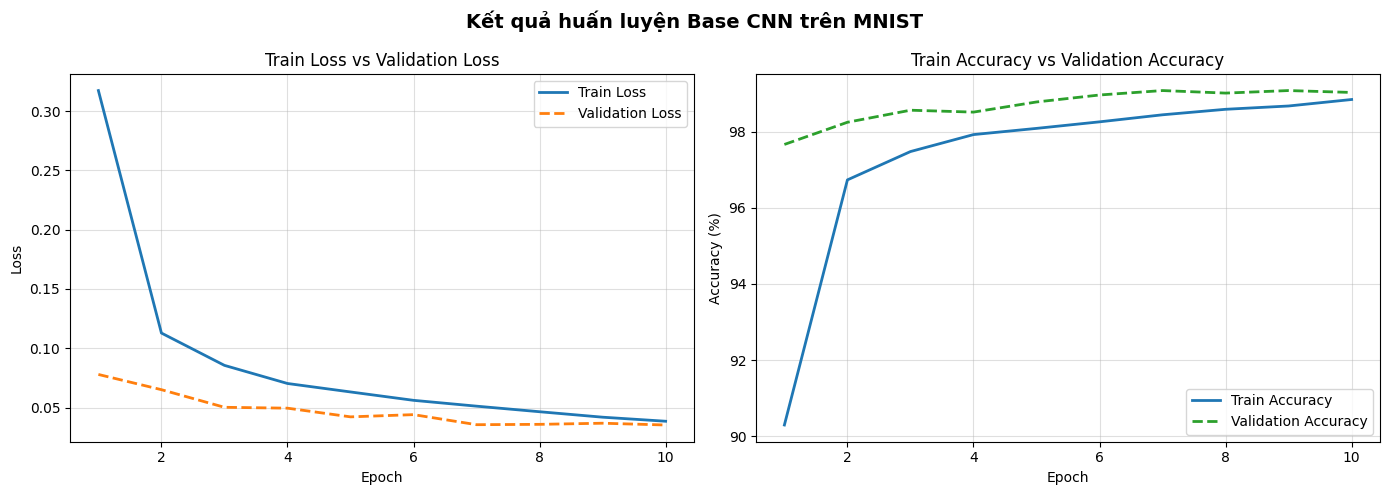

Đã lưu đồ thị vào 'training_curves.png'


In [8]:
epochs_range = range(1, EPOCHS + 1)  # Trục x: số epoch từ 1 đến N

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Kết quả huấn luyện Base CNN trên MNIST", fontsize=14, fontweight='bold')

# ── Đồ thị Loss ─────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs_range, history['train_loss'], label='Train Loss',      color='#1f77b4', linewidth=2)
ax1.plot(epochs_range, history['val_loss'],   label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Train Loss vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.4)

# ── Đồ thị Accuracy ─────────────────────────────────────────
ax2 = axes[1]
ax2.plot(epochs_range, history['train_acc'], label='Train Accuracy',      color='#1f77b4', linewidth=2)
ax2.plot(epochs_range, history['val_acc'],   label='Validation Accuracy', color='#2ca02c', linewidth=2, linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Train Accuracy vs Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')  # Lưu ảnh để chèn vào báo cáo
plt.show()
print("Đã lưu đồ thị vào 'training_curves.png'")

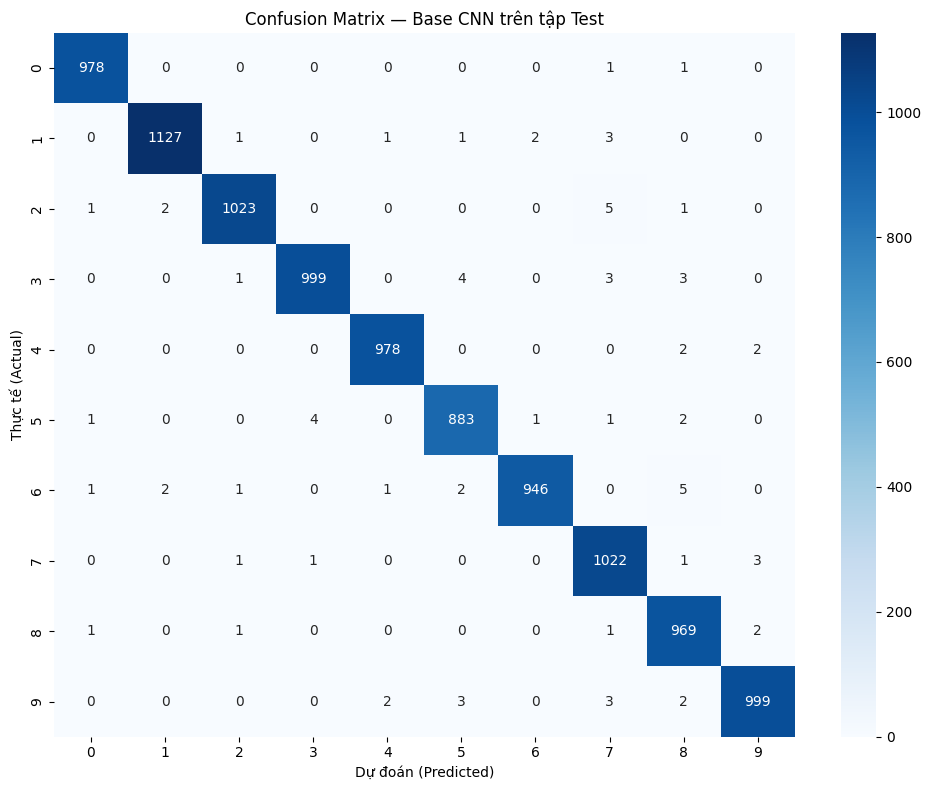


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      0.99      1135
           2       1.00      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       1.00      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [9]:
#Confustion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Thu thập toàn bộ dự đoán trên tập test
all_preds  = []
all_labels = []

test_model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = test_model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── 8.2 Confusion Matrix ────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix — Base CNN trên tập Test')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 8.3 Classification Report ───────────────────────────────
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=[str(i) for i in range(10)]))

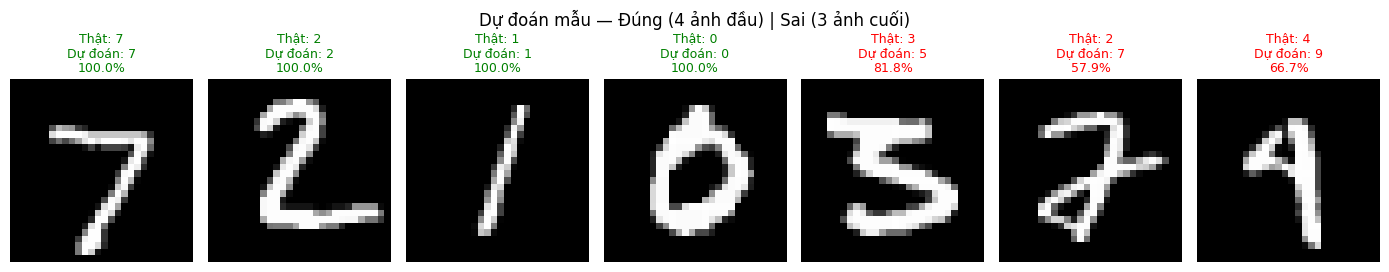

In [10]:
sample_images, sample_labels = next(iter(test_loader))

test_model.eval()
with torch.no_grad():
    outputs = test_model(sample_images.to(device))
    probs   = torch.softmax(outputs, dim=1).cpu()   # Chuyển logits -> xác suất
    preds   = probs.argmax(dim=1)

# Tìm index ảnh đúng và sai
correct_idx = (preds == sample_labels).nonzero(as_tuple=True)[0][:4]  # 4 ảnh đúng
wrong_idx   = (preds != sample_labels).nonzero(as_tuple=True)[0][:3]  # 3 ảnh sai
show_idx    = torch.cat([correct_idx, wrong_idx])

fig, axes = plt.subplots(1, len(show_idx), figsize=(14, 3))
fig.suptitle('Dự đoán mẫu — Đúng (4 ảnh đầu) | Sai (3 ảnh cuối)', fontsize=12)

for i, idx in enumerate(show_idx):
    img   = sample_images[idx].squeeze().numpy()   # Bỏ chiều channel
    true  = sample_labels[idx].item()
    pred  = preds[idx].item()
    prob  = probs[idx][pred].item() * 100
    is_ok = (true == pred)

    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    color = 'green' if is_ok else 'red'
    axes[i].set_title(
        f"Thật: {true}\nDự đoán: {pred}\n{prob:.1f}%",
        color=color, fontsize=9
    )

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150)
plt.show()

In [11]:
# Lưu state_dict (weights)
torch.save(test_model.state_dict(), 'BaseCNN_final.pt')

print("── THÔNG TIN LƯU MODEL ─────────────────────────────────")
print(f"  Tên file      : BaseCNN_final.pt")
print(f"  Định dạng     : PyTorch state_dict (.pt)")
print(f"  Val Loss tốt  : {best_val_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.2f}%")
print(f"  Dùng cho demo : Có")

── THÔNG TIN LƯU MODEL ─────────────────────────────────
  Tên file      : BaseCNN_final.pt
  Định dạng     : PyTorch state_dict (.pt)
  Val Loss tốt  : 0.0353
  Test Accuracy : 99.24%
  Dùng cho demo : Có
